In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
LAHM_loadings_table = pd.read_table('LAHM_loadings.txt', sep="\\s+", header=None)
display(LAHM_loadings_table)
LAHM_loadings = LAHM_loadings_table[4]; print(LAHM_loadings)

ISSW_loadings_table = pd.read_table('ISSW_loadings.txt', sep="\\s+", dtype=str, header=None)
display(ISSW_loadings_table)
ISSW_loadings = ISSW_loadings_table[7]; ISSW_loadings = ISSW_loadings.astype(float); print(ISSW_loadings)
labels = ISSW_loadings_table[6]; print(labels)

,0,1,2,3,4,5,6
0,Rainier,(UPS,UPS,UPS)/2025-07-03-01-1A/run_1.txt,11.399083,455.963336,6.587751
1,Rainier,(UPS,UPS,UPS)/2025-07-03-01-1B/run_1.txt,9.729194,389.167757,6.181192
2,Rainier,(UPS,UPS,UPS)/2025-07-03-01-2A/run_1.txt,8.276143,59.115309,4.374409
3,Rainier,(UPS,UPS,UPS)/2025-07-03-01-3A/run_1.txt,8.372626,41.863131,4.274290
4,Rainier,(UPS,UPS,UPS)/2025-07-03-01-4A/run_1.txt,8.062483,11.197894,4.276471
5,Rainier,(UPS,UPS,UPS)/2025-07-03-01-5A/run_1.txt,8.834798,12.443378,4.140303
6,Rainier,(UPS,UPS,UPS)/2025-07-03-01-6/run_1.txt,6.548085,4.424382,4.384542


0    11.399083
1     9.729194
2     8.276143
3     8.372626
4     8.062483
5     8.834798
6     6.548085
Name: 4, dtype: float64


,0,1,2,3,4,5,6,7,8,9
0,std-equivalent,loading,"@450,","600,",AAE,=,file_1A.txt,32.49120752054433,24.78669549274759,1.3972487704295826
1,std-equivalent,loading,"@450,","600,",AAE,=,file_1B.txt,22.112803413720787,15.348477757702069,1.725659929193523
2,std-equivalent,loading,"@450,","600,",AAE,=,file_2A.txt,10.628008153269024,7.789574220735244,1.536444500364524
3,std-equivalent,loading,"@450,","600,",AAE,=,file_3A.txt,11.378883578941691,7.68160847574955,1.8222591964531871
4,std-equivalent,loading,"@450,","600,",AAE,=,file_4A.txt,19.290780891277056,13.681842119052924,1.6506370626957825
5,std-equivalent,loading,"@450,","600,",AAE,=,file_5A.txt,19.358151849054934,14.507764778970737,1.4590083682761197
6,std-equivalent,loading,"@450,","600,",AAE,=,file_6.txt,18.134748881802874,14.858669119920245,1.149002413965819


0    32.491208
1    22.112803
2    10.628008
3    11.378884
4    19.290781
5    19.358152
6    18.134749
Name: 7, dtype: float64
0    file_1A.txt
1    file_1B.txt
2    file_2A.txt
3    file_3A.txt
4    file_4A.txt
5    file_5A.txt
6     file_6.txt
Name: 6, dtype: str


[ 2.21088718e+00 -1.95989407e-04]
n =  8


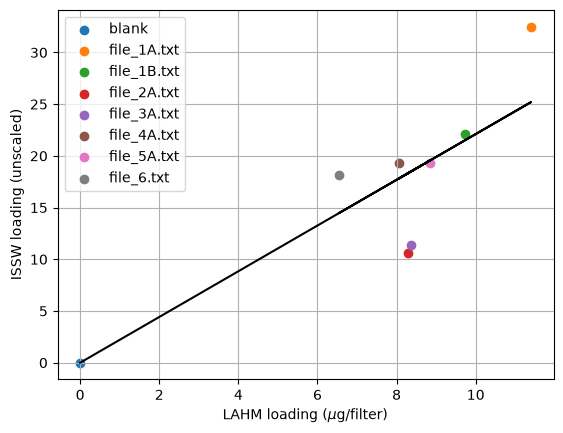

In [18]:
LAHM_loadings_ext = np.append(0,LAHM_loadings)
ISSW_loadings_ext = np.append(0,ISSW_loadings)
labels_ext = np.append('blank',labels)
weights = np.ones(np.shape(LAHM_loadings_ext)); weights[0]=100

p = np.polyfit(LAHM_loadings_ext,ISSW_loadings_ext,1,w=weights); print(p)
n = len(LAHM_loadings_ext); print('n = ', n)

plt.figure()
for i in range(n):
    plt.scatter(LAHM_loadings_ext[i],ISSW_loadings_ext[i],label=labels_ext[i])
plt.grid(True)
plt.xlabel(r'LAHM loading ($\mu$g/filter)')
plt.ylabel('ISSW loading (unscaled)')
plt.legend()
plt.plot(LAHM_loadings_ext,np.polyval(p,LAHM_loadings_ext),color='black')